<a href="https://colab.research.google.com/github/Ersaoktaviannn/eeg-creative-state-classifier/blob/dev/EEG_Primary_Secondary-v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Sel instalasi dependensi
%pip -q install "decorator>=4.0.2,<5.0" "mne==1.6.1" "jedi>=0.16" "PyWavelets>=1.4" "h5py>=3.8" "joblib>=1.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 120.7 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 1 — KONFIGURASI & IMPORT
# ============================================================

from google.colab import drive
from pathlib import Path
import json, re, warnings, h5py, joblib, mne, pywt, decorator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import ipywidgets as widgets

from math import gcd
from hashlib import sha1
from IPython.display import display, clear_output
from scipy.signal import butter, detrend, resample_poly, sosfiltfilt, welch
from scipy.stats import entropy

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, GroupKFold, LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler


# ============================================================
# MOUNT DRIVE
# ============================================================

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")


# ============================================================
# PATH DATASET
# ============================================================

BASE_DIR = Path("/content/drive/MyDrive/Creativity-Dataset/")

SECONDARY_DIR = BASE_DIR / "Secondary"
PRIMARY_RAW_DIR = BASE_DIR / "Primary-raw"
PRIMARY_MERGED_DIR = BASE_DIR / "Primary-merged"

PRIMARY_SEGMENTS_CSV = BASE_DIR / "primary_segments.csv"

CACHE_DIR = BASE_DIR / "cache"
PREPROCESSED_CACHE_DIR = CACHE_DIR / "preprocessed"
FEATURE_CACHE_DIR = CACHE_DIR / "features"
OUTPUT_DIR = BASE_DIR / "output"

for folder in [
    SECONDARY_DIR,
    PRIMARY_RAW_DIR,
    PRIMARY_MERGED_DIR,
    PREPROCESSED_CACHE_DIR,
    FEATURE_CACHE_DIR,
    OUTPUT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)


# ============================================================
# SIGNAL CONFIG
# ============================================================

FS_PRIMARY = 125
FS_SECONDARY = 500
FS_TARGET = 125

BANDPASS_LOW = 1.0
BANDPASS_HIGH = 40.0
FILTER_ORDER = 4

KNOWN_RAIL_ABS_THRESHOLD = 180000.0
ROBUST_OUTLIER_MAD_MULTIPLIER = 25.0

MAX_REPAIR_RATIO_PER_CHANNEL = 0.05
BAD_CHANNEL_Z_THRESHOLD = 5.0
EPOCH_ARTIFACT_Z_THRESHOLD = 5.0

WAVELET = "db4"
DWT_LEVEL = 5

ADD_SPECTRAL_FEATURES = True


# ============================================================
# IMPORTANT CONFIG UNTUK MERGED 4 KELAS
# ============================================================

# Jangan terlalu kecil.
# Kalau tetap 2, dataset kamu hanya ambil 2 subject dan merged akan sulit naik.
MAX_EPOCHS_PER_SUBJECT_CLASS = 300
DEBUG_MAX_SUBJECTS = 9999

# Run pertama harus True supaya feature cache lama tidak kepakai.
# Setelah berhasil dan ingin run ulang lebih cepat, boleh ubah ke False.
FORCE_REBUILD_FEATURES = True

# Ganti cache version agar tidak bentrok dengan hasil lama.
CACHE_VERSION = "v4_merged_4class_fullsubjects"

RANDOM_STATE = 42


# ============================================================
# EXPERIMENT CONFIG
# Nanti cell patch baru tetap punya config sendiri.
# Ini disiapkan agar cell lama sebelum patch tidak error.
# ============================================================

EXPERIMENT_CONFIGS = [
    {
        "epoch_seconds": 2.0,
        "overlap_ratio": 0.75,
        "primary_trim_seconds": 2.0,
    },
    {
        "epoch_seconds": 2.0,
        "overlap_ratio": 0.50,
        "primary_trim_seconds": 2.0,
    },
    {
        "epoch_seconds": 4.0,
        "overlap_ratio": 0.50,
        "primary_trim_seconds": 2.0,
    },
    {
        "epoch_seconds": 4.0,
        "overlap_ratio": 0.25,
        "primary_trim_seconds": 2.0,
    },
]


# ============================================================
# DATASET MODE
# ============================================================

# Untuk notebook lama, mode gabungan biasanya disebut "combined".
# Nanti di cell patch baru, mode ini akan dioverride menjadi "merged".
# Jadi di Cell 1 pakai "combined" supaya tetap cocok dengan struktur notebook lama.
DATASET_MODE = "combined"


# ============================================================
# PRIMARY INPUT MODE
# ============================================================

# Pakai "separate" kalau data primary kamu masih per folder/aktivitas:
# Primary-raw/RST1, Primary-raw/IDG, Primary-raw/IDE, Primary-raw/IDR, RST2
#
# Pakai "merged" kalau data primary sudah berupa file .mat per subject di Primary-merged.
PRIMARY_INPUT_MODE = "separate"


# ============================================================
# FILE SELECTION
# ============================================================

# Biarkan kosong.
# Cell patch baru akan auto-select semua file .mat.
MANUAL_SELECTED_FILES = []


print("Environment Ready")
print("DATASET_MODE              :", DATASET_MODE)
print("PRIMARY_INPUT_MODE        :", PRIMARY_INPUT_MODE)
print("DEBUG_MAX_SUBJECTS        :", DEBUG_MAX_SUBJECTS)
print("FORCE_REBUILD_FEATURES    :", FORCE_REBUILD_FEATURES)
print("CACHE_VERSION             :", CACHE_VERSION)

Mounted at /content/drive
Environment Ready
DATASET_MODE              : combined
PRIMARY_INPUT_MODE        : separate
DEBUG_MAX_SUBJECTS        : 9999
FORCE_REBUILD_FEATURES    : True
CACHE_VERSION             : v4_merged_4class_fullsubjects


In [3]:
# ============================================================
# LABEL & KANAL
# ============================================================

LABELS = ["RST1", "IDG", "IDE", "IDR", "RST2"]
PRIMARY_CHANNELS_ORIGINAL = ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "C3", "C4", "T3", "T4", "T5", "T6", "P3", "P4", "O1", "O2"]
CANONICAL_CHANNELS = ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "C3", "C4", "T7", "T8", "P7", "P8", "P3", "P4", "O1", "O2"]

SECONDARY_CHANNELS_64 = [
    "Fp1", "Fp2", "Fpz", "AF3", "AF4", "AF7", "AF8", "AFz", "F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "Fz",
    "FT7", "FT8", "FC1", "FC2", "FC3", "FC4", "FC5", "FC6", "FCz", "T7", "T8", "C1", "C2", "C3", "C4", "C5", "C6", "Cz",
    "TP7", "TP8", "CP1", "CP2", "CP3", "CP4", "CP5", "CP6", "CPz", "P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8",
    "P9", "P10", "Pz", "PO3", "PO4", "PO7", "PO8", "POz", "O1", "O2", "Oz", "Iz"
]

SECONDARY_CHANNELS_63 = [ch for ch in SECONDARY_CHANNELS_64 if ch != "Cz"]
SECONDARY_SELECTED_INDICES = [SECONDARY_CHANNELS_63.index(ch) for ch in CANONICAL_CHANNELS]

def normalize_label(text):
    text = str(text).upper()
    for label in LABELS:
        if label in text: return label
    return None

def infer_subject_id(text, prefix):
    match = re.search(r"SUB(?:JECT)?[_\-\s]*(\d+)", str(text), flags=re.IGNORECASE)
    if not match: raise ValueError(f"Nomor subjek tidak ditemukan: {text}")
    return f"{prefix}_{int(match.group(1)):03d}"

def stable_name(text):
    return sha1(str(text).encode("utf-8")).hexdigest()[:16]

channel_mapping_df = pd.DataFrame({"kanal_primer": PRIMARY_CHANNELS_ORIGINAL, "kanal_harmonisasi": CANONICAL_CHANNELS, "idx_sekunder": SECONDARY_SELECTED_INDICES})
display(channel_mapping_df)
print("Index 16 kanal sekunder:", SECONDARY_SELECTED_INDICES)

,kanal_primer,kanal_harmonisasi,idx_sekunder
0,Fp1,Fp1,0
1,Fp2,Fp2,1
2,F3,F3,10
3,F4,F4,11
4,F7,F7,14
5,F8,F8,15
6,C3,C3,30
7,C4,C4,31
8,T3,T7,26
9,T4,T8,27


Index 16 kanal sekunder: [0, 1, 10, 11, 14, 15, 30, 31, 26, 27, 49, 50, 45, 46, 59, 60]


In [4]:
import re
from pathlib import Path
import scipy.io as sio
import h5py
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from hashlib import sha1

# --- HELPER FUNCTIONS ---
def load_record_eeg(ref):
    arr = load_mat_variable(ref['file_path'], ref['mat_key'])
    if ref['source'] == 'secondary':
        eeg = arr if arr.shape[0] == 63 else arr.T
        return eeg[SECONDARY_SELECTED_INDICES, :].astype(float), None
    eeg, log = extract_primary_eeg(arr)
    return eeg.astype(float), log

def list_mat_variables(file_path):
    file_path = Path(file_path)
    try: return [(name, tuple(shape), dtype) for name, shape, dtype in sio.whosmat(file_path)]
    except:
        results = []
        with h5py.File(file_path, 'r') as handle:
            def visitor(name, obj):
                if isinstance(obj, h5py.Dataset): results.append((name, tuple(obj.shape), str(obj.dtype)))
            handle.visititems(visitor)
        return results

def load_mat_variable(file_path, key):
    try:
        mat = sio.loadmat(file_path, variable_names=[key])
        return np.asarray(mat[key])
    except:
        with h5py.File(file_path, 'r') as handle: return np.asarray(handle[key])

def extract_primary_eeg(arr):
    arr = np.asarray(arr, dtype=float)
    d = arr if arr.shape[1] in {16, 17} else arr.T
    if d.shape[1] == 17: return d[:, 1:17].T, None
    return d[:, :16].T, None

def detect_file_source(path):
    f = Path(path).resolve()
    if f.is_relative_to(SECONDARY_DIR.resolve()): return 'secondary'
    return 'primary'

def get_all_available_files():
    sec = sorted(SECONDARY_DIR.rglob('*.mat'))
    pri_raw = sorted(PRIMARY_RAW_DIR.rglob('*.mat'))
    pri_merged = sorted(PRIMARY_MERGED_DIR.rglob('*.mat'))
    if DATASET_MODE == 'secondary': return sec
    if DATASET_MODE == 'primary': return pri_merged if PRIMARY_INPUT_MODE == 'merged' else pri_raw
    return sec + pri_merged + pri_raw

def choose_primary_key(file_path):
    vars = list_mat_variables(file_path)
    cands = [(int(np.prod(s)), n) for n, s, _ in vars if len(s) == 2]
    if not cands: raise ValueError(f"No 2D array in {file_path}")
    avail_vars = [n for _, n in cands]
    return "data" if "data" in avail_vars else max(cands, key=lambda x: x[0])[1]

def discover_selected_refs(paths):
    res = []
    for p in paths:
        f = Path(p); src = detect_file_source(f)
        sid = infer_subject_id(f.stem, "SEC" if src == "secondary" else "PRI")
        if src == "secondary":
            vars = list_mat_variables(f)
            for k, s, _ in vars:
                lbl = normalize_label(k)
                if lbl and len(s) == 2 and 63 in s:
                    res.append({"source": "secondary", "subject_id": sid, "record_id": f"{sid}__{k}", "label": lbl, "file_path": str(f), "mat_key": k, "sfreq": FS_SECONDARY})
        else:
            lbl = normalize_label(f.stem)
            if lbl is None:
                print(f"Lewati file primer tanpa label: {f.name}")
                continue
            res.append({"source": "primary", "subject_id": sid, "record_id": f"{sid}__{f.stem}", "label": lbl, "file_path": str(f), "mat_key": choose_primary_key(f), "sfreq": FS_PRIMARY})
    return res

def on_process_clicked(b):
    with output_area:
        clear_output()
        if not file_selector.value: print("Pilih file dulu."); return
        try:
            global refs, refs_df, record_count_df, MANUAL_SELECTED_FILES
            refs = discover_selected_refs(file_selector.value)
            if not refs: raise ValueError("Tidak ada record valid yang ditemukan.")
            refs_df = pd.DataFrame(refs)
            record_count_df = refs_df.groupby(["source", "subject_id", "label"]).size().reset_index(name="count")
            MANUAL_SELECTED_FILES = list(file_selector.value)
            display(record_count_df)
            print(f"Siap: {len(refs)} record terdeteksi.")
        except Exception as e: print(f"Gagal: {e}")

avail_files = get_all_available_files()
opts_data = [(f'[{detect_file_source(f).upper()}] {f.name}', str(f)) for f in avail_files]
file_selector = widgets.SelectMultiple(options=opts_data, layout={'width': '100%', 'height': '200px'})
btn_proc = widgets.Button(description='Proses File Terpilih', button_style='success')
output_area = widgets.Output()
btn_proc.on_click(on_process_clicked)
display(widgets.VBox([widgets.HTML('<b>Pilih file MAT (Ctrl+Klik):</b>'), file_selector, btn_proc, output_area]))

In [5]:
# ============================================================
# PREPROCESSING UTILS & CACHE
# ============================================================
def robust_zscore(v):
    v = np.asarray(v, dtype=float)
    if v.size == 0: return v
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    return 0.6745 * (v - med) / (mad + 1e-12) if mad > 1e-12 else np.zeros_like(v)

def interpolate_invalid_1d(sig, mask):
    return pd.Series(sig).mask(mask).interpolate(limit_direction="both").bfill().ffill().values

def repair_primary_invalid_samples(eeg):
    eeg, logs = eeg.copy(), []
    for i, ch in enumerate(CANONICAL_CHANNELS):
        sig, fin = eeg[i], eeg[i][np.isfinite(eeg[i])]
        if fin.size == 0:
            mask = np.ones_like(sig, dtype=bool)
        else:
            med = np.median(fin)
            mad = np.median(np.abs(fin-med))
            scale = 1.4826 * mad if mad > 1e-12 else (np.std(fin) + 1e-12)
            mask = ~np.isfinite(sig) | (np.abs(sig) >= KNOWN_RAIL_ABS_THRESHOLD)
            mask |= (np.abs(sig - med) > (ROBUST_OUTLIER_MAD_MULTIPLIER * scale))

        if mask.mean() > MAX_REPAIR_RATIO_PER_CHANNEL: raise ValueError(f"{ch} too many bad samples")
        if mask.any(): eeg[i] = interpolate_invalid_1d(sig, mask)
        logs.append({"ch": ch, "count": int(mask.sum()), "ratio": mask.mean()})
    return eeg, logs

def apply_bandpass(eeg, sfreq):
    eeg = detrend(eeg, axis=1, type="linear")
    sos = butter(FILTER_ORDER, [BANDPASS_LOW, BANDPASS_HIGH], btype="bandpass", fs=sfreq, output="sos")
    return sosfiltfilt(sos, eeg, axis=1)

def detect_bad_channels(eeg):
    std = np.std(eeg, axis=1)
    return (std < 1e-10) | (np.abs(robust_zscore(np.log10(std + 1e-12))) > BAD_CHANNEL_Z_THRESHOLD)

def interpolate_bad_channels(eeg, sfreq, mask):
    bads = [ch for ch, is_bad in zip(CANONICAL_CHANNELS, mask) if is_bad]
    if not bads: return eeg, []
    if len(bads) > 6: raise ValueError(f"Too many bad channels ({len(bads)}): {bads}")
    raw = mne.io.RawArray(eeg, mne.create_info(CANONICAL_CHANNELS, sfreq, "eeg"), verbose=0)
    raw.set_montage("standard_1020", on_missing="ignore"); raw.info["bads"] = bads
    return raw.interpolate_bads(reset_bads=True, verbose=0).get_data(), bads

def preprocess_record(ref):
    eeg, c_log = load_record_eeg(ref)
    rep_log, bads = None, []
    if ref["source"] == "primary": eeg, rep_log = repair_primary_invalid_samples(eeg)
    eeg = apply_bandpass(eeg, ref["sfreq"])
    if ref["source"] == "primary": eeg, bads = interpolate_bad_channels(eeg, ref["sfreq"], detect_bad_channels(eeg))
    eeg = eeg - np.mean(eeg, axis=0, keepdims=True)
    if int(ref["sfreq"]) != FS_TARGET: eeg = resample_poly(eeg, FS_TARGET//gcd(int(ref["sfreq"]), FS_TARGET), int(ref["sfreq"])//gcd(int(ref["sfreq"]), FS_TARGET), axis=1)
    return eeg.astype(np.float32), {"counter": c_log, "repair": rep_log, "bad_channels": bads}

def preprocessed_cache_path(ref):
    stamp = f"{Path(ref['file_path']).stat().st_size}__{Path(ref['file_path']).stat().st_mtime_ns}"
    ident = f"{CACHE_VERSION}__{ref['record_id']}__{stamp}__{ref.get('start_sec','')}__{ref.get('end_sec','')}"
    return PREPROCESSED_CACHE_DIR / f"{stable_name(ident)}.npy"

def prepare_preprocessed_cache(refs):
    rows = []
    for i, ref in enumerate(refs, 1):
        path = preprocessed_cache_path(ref)
        print(f"[{i:03d}/{len(refs):03d}] {ref['record_id']}")
        if path.exists():
            eeg, log = np.load(path, mmap_mode="r"), {"cached": True}
        else:
            eeg, log = preprocess_record(ref)
            np.save(path, eeg)
        rows.append({**ref, "cache_path": str(path), "n_samples": eeg.shape[1], "duration": eeg.shape[1]/FS_TARGET, "preprocess_log": json.dumps(log, default=str)})
    return pd.DataFrame(rows)

In [6]:
# ============================================================
# FULL PATCH — MERGED DATASET 4 KELAS: RST, IDG, IDE, IDR
# Tempel sebagai CELL BARU setelah Cell 4.
# Jangan jalankan Cell 5 sampai Cell 10 lama.
# ============================================================

%pip -q install imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import joblib
import warnings

from pathlib import Path
from collections import Counter
from scipy.signal import welch, butter, sosfiltfilt, hilbert
from scipy.stats import entropy

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedGroupKFold,
    GroupKFold,
    ParameterSampler
)
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)
from imblearn.over_sampling import RandomOverSampler, SMOTE

warnings.filterwarnings("ignore")


# ============================================================
# 1. SETTING UTAMA
# ============================================================

DATASET_MODE = "merged"

LABELS_RAW = ["RST1", "IDG", "IDE", "IDR", "RST2"]
TARGET_LABELS = ["RST", "IDG", "IDE", "IDR"]

# Mode evaluasi:
# "auto"  = kalau subjek < 4, otomatis epoch-level CV agar eksperimen tidak mentok.
# "group" = subject-wise CV, lebih valid untuk klaim skripsi, tapi bisa rendah jika subjek sedikit.
# "epoch" = epoch-level CV, biasanya akurasi tinggi, tapi bukan generalisasi subject-wise.
CV_MODE = "auto"

AUTO_SELECT_ALL_FILES = True

FORCE_REBUILD_FEATURES = True
CACHE_VERSION = "run_merged_4class_fixed_v1"

# Feature settings
DWT_LEVEL_TARGET = 5
DWT_COEFFS_NAMES = ["A5", "D5", "D4", "D3", "D2", "D1"]

ADD_SPECTRAL_FEATURES = True
ADD_CONNECTIVITY_FEATURES = True
ADD_DERIVED_FEATURES = True

# Agar IDR secondary yang sedikit tidak kalah total oleh kelas lain
MAX_EPOCHS_PER_SUBJECT_CLASS = 300

# Tuning
N_PARAM_TRIALS = 35
RANDOM_STATE = 42

# Domain normalization
ALLOW_TEST_SELF_NORMALIZATION = True
APPLY_CORAL = True
CORAL_REG = 1e-4

# Eksperimen epoch
EXPERIMENT_CONFIGS = [
    {"epoch_seconds": 2.0, "overlap_ratio": 0.75, "primary_trim_seconds": 2.0},
    {"epoch_seconds": 2.0, "overlap_ratio": 0.50, "primary_trim_seconds": 2.0},
    {"epoch_seconds": 4.0, "overlap_ratio": 0.50, "primary_trim_seconds": 2.0},
    {"epoch_seconds": 4.0, "overlap_ratio": 0.25, "primary_trim_seconds": 2.0},
]

print("PATCH 4 KELAS AKTIF")
print("Target labels:", TARGET_LABELS)
print("CV_MODE      :", CV_MODE)
print("CACHE_VERSION:", CACHE_VERSION)


# ============================================================
# 2. LABEL MAPPING
# ============================================================

def normalize_label(text):
    text = str(text).upper()
    for label in LABELS_RAW:
        if label in text:
            return label
    return None


def remap_to_4class(raw_label):
    if raw_label in ("RST1", "RST2"):
        return "RST"
    if raw_label in ("IDG", "IDE", "IDR"):
        return raw_label
    return None


# ============================================================
# 3. AUTO SELECT FILE
# ============================================================

def get_selected_files_for_merged():
    sec_files = sorted(SECONDARY_DIR.rglob("*.mat"))

    if PRIMARY_INPUT_MODE == "merged":
        pri_files = sorted(PRIMARY_MERGED_DIR.rglob("*.mat"))
    else:
        pri_files = sorted(PRIMARY_RAW_DIR.rglob("*.mat"))

    if DATASET_MODE == "secondary":
        return sec_files
    if DATASET_MODE == "primary":
        return pri_files

    return sec_files + pri_files


if AUTO_SELECT_ALL_FILES:
    selected_files = get_selected_files_for_merged()
    MANUAL_SELECTED_FILES = [str(f) for f in selected_files]
    refs = discover_selected_refs(MANUAL_SELECTED_FILES)

    if len(refs) == 0:
        raise ValueError("Tidak ada file valid ditemukan. Cek folder Secondary / Primary-raw / Primary-merged.")

    refs_df = pd.DataFrame(refs)

    print("\nJumlah record terdeteksi:", len(refs_df))
    display(refs_df.groupby(["source", "subject_id", "label"]).size().reset_index(name="records"))
    print("Jumlah group/subjek unik:", refs_df["subject_id"].nunique())
    display(refs_df.groupby("source")["subject_id"].nunique().reset_index(name="n_subjects"))


# ============================================================
# 4. BASIC UTILS
# ============================================================

def epoch_starts(n, sec, overlap, trim):
    size = int(sec * FS_TARGET)
    step = int(size * (1 - overlap))
    trim_size = int(trim * FS_TARGET)

    if step <= 0:
        raise ValueError("Overlap terlalu besar. Step menjadi <= 0.")

    if (n - 2 * trim_size) >= size:
        starts = list(range(trim_size, n - trim_size - size + 1, step))
    else:
        starts = []

    return starts, size


def robust_zscore(v):
    v = np.asarray(v, dtype=float)
    if v.size == 0:
        return v
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    if mad <= 1e-12:
        return np.zeros_like(v)
    return 0.6745 * (v - med) / (mad + 1e-12)


def screen_epoch_starts(eeg, starts, size):
    if not starts:
        return []

    epochs = np.stack([eeg[:, s:s + size] for s in starts])

    ptp = np.max(np.ptp(epochs, axis=2), axis=1)
    grad = np.max(np.mean(np.abs(np.diff(epochs, axis=2)), axis=2), axis=1)

    mask = (
        (np.abs(robust_zscore(np.log10(ptp + 1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD)
        &
        (np.abs(robust_zscore(np.log10(grad + 1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD)
    )

    return [s for s, keep in zip(starts, mask) if keep]


def hjorth_parameters(sig):
    sig = np.asarray(sig, dtype=float)

    activity = np.var(sig)

    if activity <= 1e-18:
        return 0.0, 0.0, 0.0

    d1 = np.diff(sig)
    d2 = np.diff(sig, n=2)

    var_d1 = np.var(d1)
    var_d2 = np.var(d2)

    mobility = np.sqrt(var_d1 / activity)

    if var_d1 <= 1e-18 or mobility <= 1e-18:
        complexity = 0.0
    else:
        complexity = np.sqrt(var_d2 / var_d1) / mobility

    return float(activity), float(mobility), float(complexity)


# ============================================================
# 5. FEATURE EXTRACTION — DWT FIXED LEVEL + SPECTRAL + PLV
# ============================================================

DWT_COLS = [
    f"{ch}__{coeff}__{param}"
    for ch in CANONICAL_CHANNELS
    for coeff in DWT_COEFFS_NAMES
    for param in ["activity", "mobility", "complexity"]
]

FREQUENCY_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}

SPEC_COLS = [
    f"{ch}__spectral__{param}"
    for ch in CANONICAL_CHANNELS
    for param in [*FREQUENCY_BANDS.keys(), "entropy"]
]

CONNECTIVITY_PAIRS = (
    [("F3", "F4"), ("F7", "F8"), ("Fp1", "Fp2")]
    + [("F3", "P3"), ("F4", "P4"), ("F7", "P7"), ("F8", "P8")]
    + [("F3", "O1"), ("F4", "O2")]
    + [("T7", "T8"), ("P7", "P8")]
    + [("C3", "P3"), ("C4", "P4"), ("C3", "C4")]
)

CONNECTIVITY_BANDS = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
}

CONNECTIVITY_COLS = [
    f"plv__{ch1}_{ch2}__{band}"
    for ch1, ch2 in CONNECTIVITY_PAIRS
    for band in CONNECTIVITY_BANDS
]

BASE_FEATURE_COLUMNS = DWT_COLS + (SPEC_COLS if ADD_SPECTRAL_FEATURES else [])
if ADD_CONNECTIVITY_FEATURES:
    BASE_FEATURE_COLUMNS = BASE_FEATURE_COLUMNS + CONNECTIVITY_COLS

print("\nJumlah fitur dasar:")
print("DWT       :", len(DWT_COLS))
print("Spectral  :", len(SPEC_COLS) if ADD_SPECTRAL_FEATURES else 0)
print("PLV       :", len(CONNECTIVITY_COLS) if ADD_CONNECTIVITY_FEATURES else 0)
print("Total base:", len(BASE_FEATURE_COLUMNS))


def extract_dwt_hjorth_features(epoch):
    feats = []

    for sig in epoch:
        sig = np.asarray(sig, dtype=float)

        max_level = pywt.dwt_max_level(len(sig), pywt.Wavelet(WAVELET).dec_len)
        level = min(DWT_LEVEL_TARGET, max_level)

        if level < 1:
            coeff_map = {}
        else:
            coeffs = pywt.wavedec(sig, WAVELET, level=level, mode="periodization")

            coeff_map = {}

            coeff_map[f"A{level}"] = coeffs[0]

            # coeffs[1:] = D_level, D_level-1, ..., D1
            for idx, c in enumerate(coeffs[1:]):
                detail_level = level - idx
                coeff_map[f"D{detail_level}"] = c

        for coeff_name in DWT_COEFFS_NAMES:
            if coeff_name in coeff_map:
                feats.extend(hjorth_parameters(coeff_map[coeff_name]))
            else:
                feats.extend([0.0, 0.0, 0.0])

    return feats


def extract_spectral_features(epoch):
    feats = []
    n_samples = epoch.shape[1]
    nperseg = min(n_samples, 2 * FS_TARGET)

    for sig in epoch:
        f_arr, psd = welch(sig, fs=FS_TARGET, nperseg=nperseg)

        mask_total = (f_arr >= 1.0) & (f_arr < 40.0)
        total_power = np.trapz(psd[mask_total], f_arr[mask_total]) + 1e-12

        for low, high in FREQUENCY_BANDS.values():
            mask_band = (f_arr >= low) & (f_arr < high)
            band_power = np.trapz(psd[mask_band], f_arr[mask_band])
            feats.append(float(band_power / total_power))

        psd_norm = psd / (np.sum(psd) + 1e-12)
        feats.append(float(entropy(psd_norm + 1e-12, base=2)))

    return feats


def compute_plv_band(sig1, sig2, low, high):
    sos = butter(
        4,
        [low, high],
        btype="bandpass",
        fs=FS_TARGET,
        output="sos",
    )

    s1 = sosfiltfilt(sos, sig1.astype(float))
    s2 = sosfiltfilt(sos, sig2.astype(float))

    phi1 = np.angle(hilbert(s1))
    phi2 = np.angle(hilbert(s2))

    return float(np.abs(np.mean(np.exp(1j * (phi1 - phi2)))))


def extract_connectivity_features(epoch):
    ch_idx = {ch: idx for idx, ch in enumerate(CANONICAL_CHANNELS)}
    feats = []

    for ch1, ch2 in CONNECTIVITY_PAIRS:
        if ch1 not in ch_idx or ch2 not in ch_idx:
            feats.extend([0.0] * len(CONNECTIVITY_BANDS))
            continue

        sig1 = epoch[ch_idx[ch1]]
        sig2 = epoch[ch_idx[ch2]]

        for low, high in CONNECTIVITY_BANDS.values():
            feats.append(compute_plv_band(sig1, sig2, low, high))

    return feats


def extract_features(epoch):
    feats = []

    feats.extend(extract_dwt_hjorth_features(epoch))

    if ADD_SPECTRAL_FEATURES:
        feats.extend(extract_spectral_features(epoch))

    if ADD_CONNECTIVITY_FEATURES:
        feats.extend(extract_connectivity_features(epoch))

    return feats


# ============================================================
# 6. FEATURE TABLE
# ============================================================

def config_id(cfg):
    return (
        f"epoch_{cfg['epoch_seconds']}s"
        f"__overlap_{cfg['overlap_ratio']}"
        f"__trim_{cfg['primary_trim_seconds']}s"
        f"__4class"
        f"__{CACHE_VERSION}"
    )


def feature_cache_path(cfg, prepared_records):
    fingerprint = stable_name("|".join(sorted(prepared_records["cache_path"].astype(str))))
    key = f"{DATASET_MODE}__{config_id(cfg)}__{fingerprint}"
    return FEATURE_CACHE_DIR / f"{stable_name(key)}.pkl"


def build_feature_table(prepared_records, config):
    descriptors = []

    for _, record in prepared_records.iterrows():
        eeg = np.load(record["cache_path"], mmap_mode="r")

        trim = (
            config["primary_trim_seconds"]
            if record["source"] == "primary"
            else 0.0
        )

        starts, size = epoch_starts(
            n=record["n_samples"],
            sec=config["epoch_seconds"],
            overlap=config["overlap_ratio"],
            trim=trim,
        )

        raw_label = record["label"]
        target_label = remap_to_4class(raw_label)

        if target_label is None:
            continue

        good_starts = screen_epoch_starts(eeg, starts, size)

        for s in good_starts:
            descriptors.append({
                "source": record["source"],
                "subject_id": record["subject_id"],
                "group_id": f"{record['source']}__{record['subject_id']}",
                "record_id": record["record_id"],
                "label": target_label,
                "raw_label": raw_label,
                "cache_path": record["cache_path"],
                "epoch_start": int(s),
                "epoch_size": int(size),
            })

    if not descriptors:
        raise ValueError("Tidak ada epoch valid. Cek label, durasi epoch, dan preprocessing.")

    desc_df = pd.DataFrame(descriptors)

    # Balance per source-subject-label agar kelas dominan tidak terlalu besar
    balanced_df = pd.concat(
        [
            g.sample(
                n=min(len(g), MAX_EPOCHS_PER_SUBJECT_CLASS),
                random_state=RANDOM_STATE,
            )
            for _, g in desc_df.groupby(["source", "subject_id", "label"], sort=False)
        ],
        ignore_index=True,
    )

    print(f"\nEpochs setelah balancing: {len(balanced_df)}")
    display(balanced_df.groupby(["source", "label"]).size().reset_index(name="epochs"))

    rows = []

    for path, group in balanced_df.groupby("cache_path", sort=False):
        eeg = np.load(path, mmap_mode="r")

        for _, d in group.iterrows():
            start = int(d["epoch_start"])
            size = int(d["epoch_size"])

            epoch = np.asarray(eeg[:, start:start + size], dtype=float)

            feats = extract_features(epoch)

            if len(feats) < len(BASE_FEATURE_COLUMNS):
                feats = feats + [0.0] * (len(BASE_FEATURE_COLUMNS) - len(feats))
            elif len(feats) > len(BASE_FEATURE_COLUMNS):
                feats = feats[:len(BASE_FEATURE_COLUMNS)]

            row = d.drop("cache_path").to_dict()
            row.update(dict(zip(BASE_FEATURE_COLUMNS, feats)))
            rows.append(row)

    feature_df = pd.DataFrame(rows)

    return feature_df


# ============================================================
# 7. DERIVED FEATURES
# ============================================================

ASYM_PAIRS = [
    ("Fp1", "Fp2"),
    ("F3", "F4"),
    ("F7", "F8"),
    ("C3", "C4"),
    ("T7", "T8"),
    ("P7", "P8"),
    ("P3", "P4"),
    ("O1", "O2"),
]

FRONTAL_CH = ["Fp1", "Fp2", "F3", "F4", "F7", "F8"]
PARIETAL_CH = ["P3", "P4", "P7", "P8"]


def add_derived_features(df, eps=1e-9):
    df = df.copy()
    new_cols = []

    # Ratio band per channel
    for ch in CANONICAL_CHANNELS:
        alpha_col = f"{ch}__spectral__alpha"
        theta_col = f"{ch}__spectral__theta"
        beta_col = f"{ch}__spectral__beta"
        gamma_col = f"{ch}__spectral__gamma"

        if alpha_col in df.columns and theta_col in df.columns:
            c = f"{ch}__ratio__alpha_theta"
            df[c] = df[alpha_col] / (df[theta_col] + eps)
            new_cols.append(c)

        if theta_col in df.columns and beta_col in df.columns:
            c = f"{ch}__ratio__theta_beta"
            df[c] = df[theta_col] / (df[beta_col] + eps)
            new_cols.append(c)

        if beta_col in df.columns and gamma_col in df.columns:
            c = f"{ch}__ratio__beta_gamma"
            df[c] = df[beta_col] / (df[gamma_col] + eps)
            new_cols.append(c)

    # Asymmetry kiri-kanan
    for left, right in ASYM_PAIRS:
        for band in ["theta", "alpha", "beta"]:
            left_col = f"{left}__spectral__{band}"
            right_col = f"{right}__spectral__{band}"

            if left_col in df.columns and right_col in df.columns:
                c = f"asym__{left}_{right}__{band}"
                df[c] = (df[right_col] - df[left_col]) / (
                    df[right_col] + df[left_col] + eps
                )
                new_cols.append(c)

    # Frontal-parietal global features
    for band in ["theta", "alpha", "beta"]:
        f_cols = [
            f"{ch}__spectral__{band}"
            for ch in FRONTAL_CH
            if f"{ch}__spectral__{band}" in df.columns
        ]

        p_cols = [
            f"{ch}__spectral__{band}"
            for ch in PARIETAL_CH
            if f"{ch}__spectral__{band}" in df.columns
        ]

        if f_cols and p_cols:
            frontal_mean = df[f_cols].mean(axis=1)
            parietal_mean = df[p_cols].mean(axis=1)

            c1 = f"global__frontal_{band}"
            c2 = f"global__parietal_{band}"
            c3 = f"global__frontal_parietal_{band}_ratio"

            df[c1] = frontal_mean
            df[c2] = parietal_mean
            df[c3] = frontal_mean / (parietal_mean + eps)

            new_cols.extend([c1, c2, c3])

    return df, new_cols


# ============================================================
# 8. NORMALIZATION + CORAL
# ============================================================

def robust_scale_fit(X):
    X = np.asarray(X, dtype=float)

    med = np.median(X, axis=0)
    mad = np.median(np.abs(X - med), axis=0)

    scale = 1.4826 * mad

    zero = scale < 1e-12
    if zero.any():
        std_fallback = X[:, zero].std(axis=0)
        scale[zero] = np.where(std_fallback > 1e-12, std_fallback, 1.0)

    return med, scale


def compute_coral_transform(X_source, X_target, reg=CORAL_REG):
    X_source = np.asarray(X_source, dtype=float)
    X_target = np.asarray(X_target, dtype=float)

    n_source, d = X_source.shape
    n_target = X_target.shape[0]

    min_samples_for_cov = max(10, d // 3)

    mu_source = X_source.mean(axis=0)
    mu_target = X_target.mean(axis=0)

    if n_source < min_samples_for_cov or n_target < min_samples_for_cov:
        return np.eye(d), mu_source, mu_target

    cov_source = np.cov(X_source - mu_source, rowvar=False) + reg * np.eye(d)
    cov_target = np.cov(X_target - mu_target, rowvar=False) + reg * np.eye(d)

    eig_s, vec_s = np.linalg.eigh(cov_source)
    eig_t, vec_t = np.linalg.eigh(cov_target)

    eig_s = np.maximum(eig_s, reg)
    eig_t = np.maximum(eig_t, reg)

    source_inv_sqrt = vec_s @ np.diag(1.0 / np.sqrt(eig_s)) @ vec_s.T
    target_sqrt = vec_t @ np.diag(np.sqrt(eig_t)) @ vec_t.T

    A = source_inv_sqrt @ target_sqrt

    return A, mu_source, mu_target


def apply_coral_transform(X, A, mu_source, mu_target):
    return (X - mu_source) @ A + mu_target


def normalize_per_subject_fold(X_train, groups_train, X_test, groups_test):
    X_train_out = X_train.copy().astype(float)
    X_test_out = X_test.copy().astype(float)

    subject_stats = {}

    # Fit train per subject
    for g in np.unique(groups_train):
        mask = groups_train == g
        med, scale = robust_scale_fit(X_train[mask])
        subject_stats[g] = (med, scale)
        X_train_out[mask] = (X_train[mask] - med) / scale

    # Transform test
    for g in np.unique(groups_test):
        mask = groups_test == g

        if g in subject_stats:
            med, scale = subject_stats[g]
        elif ALLOW_TEST_SELF_NORMALIZATION:
            # Unsupervised: hanya memakai distribusi X_test, tidak memakai label y_test
            med, scale = robust_scale_fit(X_test[mask])
        else:
            med = np.zeros(X_test.shape[1])
            scale = np.ones(X_test.shape[1])

        X_test_out[mask] = (X_test[mask] - med) / scale

    # CORAL primary -> secondary jika train punya dua domain
    if APPLY_CORAL and DATASET_MODE == "merged":
        primary_train = np.array([str(g).startswith("primary__") for g in groups_train])
        secondary_train = np.array([str(g).startswith("secondary__") for g in groups_train])

        if primary_train.sum() > 5 and secondary_train.sum() > 5:
            A, mu_source, mu_target = compute_coral_transform(
                X_train_out[primary_train],
                X_train_out[secondary_train],
            )

            X_train_out[primary_train] = apply_coral_transform(
                X_train_out[primary_train],
                A,
                mu_source,
                mu_target,
            )

            primary_test = np.array([str(g).startswith("primary__") for g in groups_test])

            if primary_test.sum() > 0:
                X_test_out[primary_test] = apply_coral_transform(
                    X_test_out[primary_test],
                    A,
                    mu_source,
                    mu_target,
                )

    return X_train_out, X_test_out


# ============================================================
# 9. CROSS VALIDATION SPLIT
# ============================================================

def cv_splits(y, groups, n_splits=5):
    y = np.asarray(y)
    groups = np.asarray(groups)

    unique_groups = np.unique(groups)
    n_groups = len(unique_groups)

    selected_mode = CV_MODE

    if selected_mode == "auto":
        if n_groups >= 4:
            selected_mode = "group"
        else:
            selected_mode = "epoch"

    if selected_mode == "group":
        actual_splits = min(n_splits, n_groups)

        if actual_splits < 2:
            raise ValueError("Group CV butuh minimal 2 group/subjek.")

        source_labels = np.array([str(g).split("__")[0] for g in groups])
        strata = np.array([f"{src}|{label}" for src, label in zip(source_labels, y)])

        try:
            print(f"CV: StratifiedGroupKFold(k={actual_splits})")
            sgkf = StratifiedGroupKFold(
                n_splits=actual_splits,
                shuffle=True,
                random_state=RANDOM_STATE,
            )

            for train_idx, test_idx in sgkf.split(np.zeros(len(y)), strata, groups=groups):
                yield train_idx, test_idx

        except Exception as e:
            print("StratifiedGroupKFold gagal, fallback GroupKFold:", e)

            gkf = GroupKFold(n_splits=actual_splits)

            for train_idx, test_idx in gkf.split(np.zeros(len(y)), y, groups):
                yield train_idx, test_idx

    elif selected_mode == "epoch":
        print("CV: StratifiedKFold epoch-level. Ini eksploratif, bukan validasi antar-subjek.")

        min_class = min(Counter(y).values())
        actual_splits = min(5, min_class)

        if actual_splits < 2:
            raise ValueError("Data tiap kelas terlalu sedikit untuk StratifiedKFold.")

        skf = StratifiedKFold(
            n_splits=actual_splits,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        for train_idx, test_idx in skf.split(np.zeros(len(y)), y):
            yield train_idx, test_idx

    else:
        raise ValueError("CV_MODE harus 'auto', 'group', atau 'epoch'.")


# ============================================================
# 10. OVERSAMPLING + MODEL
# ============================================================

def safe_oversample(X_train, y_train, k_neighbors=3):
    counts = Counter(y_train)
    min_count = min(counts.values())

    # Jika kelas sangat kecil, SMOTE tidak aman. Pakai RandomOverSampler.
    if min_count < 4:
        sampler = RandomOverSampler(
            sampling_strategy="not majority",
            random_state=RANDOM_STATE,
        )
        return sampler.fit_resample(X_train, y_train)

    try:
        sampler = SMOTE(
            sampling_strategy="not majority",
            k_neighbors=min(k_neighbors, min_count - 1),
            random_state=RANDOM_STATE,
        )
        return sampler.fit_resample(X_train, y_train)
    except Exception:
        sampler = RandomOverSampler(
            sampling_strategy="not majority",
            random_state=RANDOM_STATE,
        )
        return sampler.fit_resample(X_train, y_train)


def make_model(params, n_features_available):
    select_k = int(min(params["select_k"], n_features_available))

    svm = SVC(
        C=params["svm_C"],
        gamma=params["svm_gamma"],
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )

    rf = RandomForestClassifier(
        n_estimators=params["rf_n"],
        max_depth=params["rf_depth"],
        min_samples_leaf=params["rf_leaf"],
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    et = ExtraTreesClassifier(
        n_estimators=params["et_n"],
        max_depth=params["et_depth"],
        min_samples_leaf=params["et_leaf"],
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    knn = KNeighborsClassifier(
        n_neighbors=params["knn_k"],
        weights=params["knn_weights"],
        metric=params["knn_metric"],
    )

    ensemble = VotingClassifier(
        estimators=[
            ("svm", svm),
            ("rf", rf),
            ("et", et),
            ("knn", knn),
        ],
        voting="soft",
        weights=params["vote_weights"],
        n_jobs=-1,
    )

    pipe = Pipeline([
        ("scaler", RobustScaler()),
        ("select", SelectKBest(score_func=f_classif, k=select_k)),
        ("ensemble", ensemble),
    ])

    return pipe


PARAM_DISTRIBUTIONS = {
    "select_k": [64, 96, 128, 160, 192, 240, 320, 420, 520],
    "svm_C": [0.5, 1, 2, 5, 10, 20],
    "svm_gamma": ["scale", 0.001, 0.003, 0.005, 0.01],
    "rf_n": [200, 300, 500],
    "rf_depth": [None, 10, 20, 30],
    "rf_leaf": [1, 2, 3],
    "et_n": [200, 300, 500],
    "et_depth": [None, 10, 20, 30],
    "et_leaf": [1, 2, 3],
    "knn_k": [3, 5, 7, 9, 11, 15],
    "knn_weights": ["distance", "uniform"],
    "knn_metric": ["minkowski", "manhattan"],
    "vote_weights": [
        [2, 2, 2, 1],
        [2, 3, 3, 1],
        [1, 3, 3, 1],
        [3, 2, 2, 1],
        [1, 2, 3, 1],
    ],
}


def evaluate_params_on_table(df, feature_cols, params):
    X = df[feature_cols].replace([np.inf, -np.inf], 0).fillna(0).values
    y = df["label"].astype(str).values
    groups = df["group_id"].astype(str).values

    scores = []
    all_true = []
    all_pred = []

    for train_idx, test_idx in cv_splits(y, groups, n_splits=5):
        X_train, X_test = normalize_per_subject_fold(
            X[train_idx],
            groups[train_idx],
            X[test_idx],
            groups[test_idx],
        )

        y_train = y[train_idx]
        y_test = y[test_idx]

        X_train_os, y_train_os = safe_oversample(X_train, y_train, k_neighbors=3)

        model = make_model(params, n_features_available=len(feature_cols))
        model.fit(X_train_os, y_train_os)

        pred = model.predict(X_test)

        scores.append(balanced_accuracy_score(y_test, pred))
        all_true.extend(y_test)
        all_pred.extend(pred)

    result = {
        "mean_bal_acc": float(np.mean(scores)),
        "std_bal_acc": float(np.std(scores)),
        "accuracy": float(accuracy_score(all_true, all_pred)),
        "macro_f1": float(f1_score(all_true, all_pred, average="macro", zero_division=0)),
    }

    return result, np.array(all_true), np.array(all_pred)


# ============================================================
# 11. BUILD PREPROCESSED CACHE + FEATURE TABLES
# ============================================================

prepared_records = prepare_preprocessed_cache(refs)

feature_tables = {}

for cfg in EXPERIMENT_CONFIGS:
    ident = config_id(cfg)
    cpath = feature_cache_path(cfg, prepared_records)

    print("\n" + "=" * 80)
    print("BUILD CONFIG:", ident)
    print("=" * 80)

    if cpath.exists() and not FORCE_REBUILD_FEATURES:
        f_df = pd.read_pickle(cpath)
        print("[CACHE] Loaded:", len(f_df), "epochs")
    else:
        f_df = build_feature_table(prepared_records, cfg)

        if ADD_DERIVED_FEATURES:
            f_df, derived_cols = add_derived_features(f_df)
        else:
            derived_cols = []

        f_df.to_pickle(cpath)

    feature_tables[ident] = f_df

    display(f_df.groupby(["source", "label"]).size().reset_index(name="epochs"))


# ============================================================
# 12. TUNING & EVALUASI SEMUA CONFIG
# ============================================================

all_results = []
best_bundle = None

param_candidates = list(ParameterSampler(
    PARAM_DISTRIBUTIONS,
    n_iter=N_PARAM_TRIALS,
    random_state=RANDOM_STATE,
))

print("\nJumlah kandidat parameter:", len(param_candidates))

for ident, df in feature_tables.items():
    print("\n" + "#" * 80)
    print("EVALUASI CONFIG:", ident)
    print("#" * 80)

    meta_cols = {
        "source",
        "subject_id",
        "group_id",
        "record_id",
        "label",
        "raw_label",
        "epoch_start",
        "epoch_size",
    }

    feature_cols = [
        c for c in df.columns
        if c not in meta_cols
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    print("Jumlah fitur:", len(feature_cols))
    print("Distribusi kelas:")
    print(df["label"].value_counts())

    config_best = None

    for i, params in enumerate(param_candidates, 1):
        print(f"  Trial {i:02d}/{len(param_candidates)}", end="")

        try:
            result, y_true, y_pred = evaluate_params_on_table(df, feature_cols, params)
            print(f" | bal_acc={result['mean_bal_acc']:.4f} | macro_f1={result['macro_f1']:.4f}")

            row = {
                "config_id": ident,
                "n_features": len(feature_cols),
                **result,
                "params": params,
            }

            all_results.append(row)

            if config_best is None or row["mean_bal_acc"] > config_best["mean_bal_acc"]:
                config_best = row

            if best_bundle is None or row["mean_bal_acc"] > best_bundle["row"]["mean_bal_acc"]:
                best_bundle = {
                    "row": row,
                    "df": df.copy(),
                    "feature_cols": feature_cols,
                    "y_true": y_true,
                    "y_pred": y_pred,
                }

        except Exception as e:
            print(" | GAGAL:", e)

    print("\nBEST CONFIG SEMENTARA:")
    display(pd.DataFrame([config_best]).drop(columns=["params"]))


results_df = (
    pd.DataFrame(all_results)
    .sort_values("mean_bal_acc", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("TOP 10 HASIL")
print("=" * 80)
display(results_df.drop(columns=["params"]).head(10))

FINAL_CONFIG_ID = best_bundle["row"]["config_id"]
FINAL_PARAMS = best_bundle["row"]["params"]
FINAL_FEATURE_DF = best_bundle["df"].copy()
FINAL_COLS = best_bundle["feature_cols"]

print("\nFINAL CONFIG :", FINAL_CONFIG_ID)
print("FINAL PARAMS :")
print(FINAL_PARAMS)


# ============================================================
# 13. CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

y_true = best_bundle["y_true"]
y_pred = best_bundle["y_pred"]

print("\n" + "=" * 80)
print("FINAL CLASSIFICATION REPORT — 4 KELAS")
print("=" * 80)

print("Accuracy          :", accuracy_score(y_true, y_pred))
print("Balanced Accuracy :", balanced_accuracy_score(y_true, y_pred))
print("Macro F1          :", f1_score(y_true, y_pred, average="macro", zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=TARGET_LABELS,
    zero_division=0,
))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=TARGET_LABELS,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=ax,
)
ax.set_title("Confusion Matrix — 4 Kelas: RST, IDG, IDE, IDR")
plt.tight_layout()
plt.show()


# ============================================================
# 14. FIT FINAL MODEL SEMUA DATA + SAVE MODEL
# ============================================================

X_final = (
    FINAL_FEATURE_DF[FINAL_COLS]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
    .values
)

y_final = FINAL_FEATURE_DF["label"].astype(str).values
groups_final = FINAL_FEATURE_DF["group_id"].astype(str).values

# Normalize per subject untuk final model
X_final_norm = X_final.copy().astype(float)
final_subject_stats = {}

for g in np.unique(groups_final):
    mask = groups_final == g
    med, scale = robust_scale_fit(X_final[mask])
    final_subject_stats[g] = (med, scale)
    X_final_norm[mask] = (X_final[mask] - med) / scale

# CORAL final primary -> secondary
final_coral_params = None

if APPLY_CORAL and DATASET_MODE == "merged":
    primary_mask = np.array([str(g).startswith("primary__") for g in groups_final])
    secondary_mask = np.array([str(g).startswith("secondary__") for g in groups_final])

    if primary_mask.sum() > 5 and secondary_mask.sum() > 5:
        A, mu_source, mu_target = compute_coral_transform(
            X_final_norm[primary_mask],
            X_final_norm[secondary_mask],
        )

        X_final_norm[primary_mask] = apply_coral_transform(
            X_final_norm[primary_mask],
            A,
            mu_source,
            mu_target,
        )

        final_coral_params = {
            "A": A,
            "mu_source": mu_source,
            "mu_target": mu_target,
        }

        print("Final CORAL applied: primary -> secondary")

# Oversample final training
X_final_os, y_final_os = safe_oversample(X_final_norm, y_final, k_neighbors=3)

final_model = make_model(
    FINAL_PARAMS,
    n_features_available=len(FINAL_COLS),
)

final_model.fit(X_final_os, y_final_os)

model_bundle = {
    "model": final_model,
    "dataset_mode": DATASET_MODE,
    "target_labels": TARGET_LABELS,
    "final_config_id": FINAL_CONFIG_ID,
    "final_params": FINAL_PARAMS,
    "feature_columns": FINAL_COLS,
    "channels": CANONICAL_CHANNELS,
    "sampling_rate": FS_TARGET,
    "wavelet": WAVELET,
    "dwt_level_target": DWT_LEVEL_TARGET,
    "dwt_coeff_names": DWT_COEFFS_NAMES,
    "add_spectral_features": ADD_SPECTRAL_FEATURES,
    "add_connectivity_features": ADD_CONNECTIVITY_FEATURES,
    "add_derived_features": ADD_DERIVED_FEATURES,
    "subject_stats": final_subject_stats,
    "coral_params": final_coral_params,
    "apply_coral": APPLY_CORAL,
    "cv_mode": CV_MODE,
}

model_path = OUTPUT_DIR / "ensemble_model__merged_4class_fixed.joblib"
joblib.dump(model_bundle, model_path)

results_path = OUTPUT_DIR / "results_merged_4class_fixed.csv"
results_df.to_csv(results_path, index=False)

pred_path = OUTPUT_DIR / "predictions_merged_4class_fixed.csv"
pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred,
}).to_csv(pred_path, index=False)

print("\nMODEL TERSIMPAN:")
print(model_path)

print("\nRESULTS TERSIMPAN:")
print(results_path)

print("\nPREDICTIONS TERSIMPAN:")
print(pred_path)

print("\nSELESAI.")

PATCH 4 KELAS AKTIF
Target labels: ['RST', 'IDG', 'IDE', 'IDR']
CV_MODE      : auto
CACHE_VERSION: run_merged_4class_fixed_v1

Jumlah record terdeteksi: 341


,source,subject_id,label,records
0,primary,PRI_001,IDE,3
1,primary,PRI_001,IDG,3
2,primary,PRI_001,IDR,3
3,primary,PRI_001,RST1,1
4,primary,PRI_001,RST2,1
...,...,...,...,...
150,secondary,SEC_028,IDE,3
151,secondary,SEC_028,IDG,3
152,secondary,SEC_028,IDR,3
153,secondary,SEC_028,RST1,1


Jumlah group/subjek unik: 31


,source,n_subjects
0,primary,3
1,secondary,28



Jumlah fitur dasar:
DWT       : 288
Spectral  : 96
PLV       : 42
Total base: 426
[001/341] SEC_001__Creativity_1_1_IDE
[002/341] SEC_001__Creativity_1_1_IDG
[003/341] SEC_001__Creativity_1_1_IDR
[004/341] SEC_001__Creativity_1_2_IDE
[005/341] SEC_001__Creativity_1_2_IDG
[006/341] SEC_001__Creativity_1_2_IDR
[007/341] SEC_001__Creativity_1_3_IDE
[008/341] SEC_001__Creativity_1_3_IDG
[009/341] SEC_001__Creativity_1_3_IDR
[010/341] SEC_001__Creativity_1_RST1
[011/341] SEC_001__Creativity_1_RST2
[012/341] SEC_010__Creativity_10_1_IDE
[013/341] SEC_010__Creativity_10_1_IDG
[014/341] SEC_010__Creativity_10_1_IDR
[015/341] SEC_010__Creativity_10_2_IDE
[016/341] SEC_010__Creativity_10_2_IDG
[017/341] SEC_010__Creativity_10_2_IDR
[018/341] SEC_010__Creativity_10_3_IDE
[019/341] SEC_010__Creativity_10_3_IDG
[020/341] SEC_010__Creativity_10_3_IDR
[021/341] SEC_010__Creativity_10_RST1
[022/341] SEC_010__Creativity_10_RST2
[023/341] SEC_011__Creativity_11_1_IDE
[024/341] SEC_011__Creativity_11_1_

ValueError: F4 too many bad samples

In [ ]:
# ============================================================
# EPOCHING & FEATURE EXTRACTION
# ============================================================
def epoch_starts(n, sec, overlap, trim):
    sz, step, t_sz = int(sec*FS_TARGET), int(sec*FS_TARGET*(1-overlap)), int(trim*FS_TARGET)
    if step <= 0: raise ValueError("Invalid overlap")
    return (list(range(t_sz, n-t_sz-sz+1, step)), sz) if (n - 2*t_sz) >= sz else ([], sz)

def screen_epoch_starts(eeg, starts, sz):
    if not starts: return []
    eps = np.stack([eeg[:, s:s+sz] for s in starts])
    ptp, grad = np.max(np.ptp(eps, axis=2), axis=1), np.max(np.mean(np.abs(np.diff(eps, axis=2)), axis=2), axis=1)
    mask = (np.abs(robust_zscore(np.log10(ptp+1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD) & (np.abs(robust_zscore(np.log10(grad+1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD)
    return [s for s, k in zip(starts, mask) if k]

def hjorth_parameters(sig):
    sig = np.asarray(sig, dtype=float); act = np.var(sig)
    if act <= 1e-18: return 0.0, 0.0, 0.0
    d1, d2 = np.diff(sig), np.diff(sig, n=2)
    v1, v2 = np.var(d1), np.var(d2)
    mob = np.sqrt(v1/act)
    com = (np.sqrt(v2/v1)/mob) if (v1 > 1e-18 and mob > 1e-18) else 0.0
    return float(act), float(mob), float(com)

FREQUENCY_BANDS = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,40)}

def extract_features(epoch):
    feats = []
    for sig in epoch:
        for c in pywt.wavedec(sig, WAVELET, level=DWT_LEVEL): feats.extend(hjorth_parameters(c))
    if ADD_SPECTRAL_FEATURES:
        for sig in epoch:
            f, psd = welch(sig, fs=FS_TARGET, nperseg=min(len(sig), 2*FS_TARGET))
            mask = (f >= 1.0) & (f < 40.0)
            total = np.trapz(psd[mask], f[mask]) + 1e-12
            for b_l, b_h in FREQUENCY_BANDS.values(): feats.append(float(np.trapz(psd[(f >= b_l) & (f < b_h)], f[(f >= b_l) & (f < b_h)]) / total))
            feats.append(float(entropy(psd/(psd.sum()+1e-12)+1e-12, base=2)))
    return feats

DWT_COEFFS = ["A5", "D5", "D4", "D3", "D2", "D1"]
DWT_COLS = [f"{ch}__{cf}__{p}" for ch in CANONICAL_CHANNELS for cf in DWT_COEFFS for p in ["activity", "mobility", "complexity"]]
SPEC_COLS = [f"{ch}__spectral__{p}" for ch in CANONICAL_CHANNELS for p in [*FREQUENCY_BANDS.keys(), "entropy"]]
ALL_FEATURE_COLUMNS = DWT_COLS + (SPEC_COLS if ADD_SPECTRAL_FEATURES else [])
print(f"Total features: {len(ALL_FEATURE_COLUMNS)}")

Total features: 384


In [ ]:
# ============================================================
# EXPERIMENT RUNNER & CACHING
# ============================================================
def config_id(cfg): return f"epoch_{cfg['epoch_seconds']}s__overlap_{cfg['overlap_ratio']}__trim_{cfg['primary_trim_seconds']}s__spectral_{ADD_SPECTRAL_FEATURES}__{CACHE_VERSION}"
def prepared_fingerprint(recs): return stable_name("|".join(sorted(recs["cache_path"].astype(str))))
def feature_cache_path(cfg, recs): return FEATURE_CACHE_DIR / f"{stable_name(f'{DATASET_MODE}__{config_id(cfg)}__{prepared_fingerprint(recs)}')}.pkl"

def build_feature_table(prepared_records, config):
    descriptors = []
    for _, record in prepared_records.iterrows():
        eeg = np.load(record["cache_path"], mmap_mode="r")
        starts, size = epoch_starts(record["n_samples"], config["epoch_seconds"], config["overlap_ratio"], config["primary_trim_seconds"] if record["source"] == "primary" else 0.0)
        for s in screen_epoch_starts(eeg, starts, size):
            descriptors.append({"source": record["source"], "subject_id": record["subject_id"], "group_id": f"{record['source']}__{record['subject_id']}",
                                "record_id": record["record_id"], "label": record["label"], "cache_path": record["cache_path"], "epoch_start": int(s), "epoch_size": int(size)})
    if not descriptors: raise ValueError("No epochs created.")
    df = pd.concat([g.sample(n=min(len(g), MAX_EPOCHS_PER_SUBJECT_CLASS), random_state=RANDOM_STATE) for _, g in pd.DataFrame(descriptors).groupby(["source", "subject_id", "label"], sort=False)], ignore_index=True)
    print(f"Epochs balanced: {len(df)}")
    rows = []
    for path, group in df.groupby("cache_path", sort=False):
        eeg = np.load(path, mmap_mode="r")
        for _, d in group.iterrows():
            epoch_data = np.array(eeg[:, int(d["epoch_start"]):int(d["epoch_start"])+int(d["epoch_size"])])
            rows.append({**d.drop("cache_path").to_dict(), **dict(zip(ALL_FEATURE_COLUMNS, extract_features(epoch_data)))})
    return pd.DataFrame(rows)

# Memastikan preprocessed data siap sebelum ekstraksi fitur
prepared_records = prepare_preprocessed_cache(refs)

feature_tables = {}
for config in EXPERIMENT_CONFIGS:
    ident, cpath = config_id(config), feature_cache_path(config, prepared_records)
    print(f"\n{'='*40}\nCONFIG: {ident}\n{'='*40}")
    f_df = pd.read_pickle(cpath) if (cpath.exists() and not FORCE_REBUILD_FEATURES) else build_feature_table(prepared_records, config)
    if not cpath.exists() or FORCE_REBUILD_FEATURES: f_df.to_pickle(cpath)
    feature_tables[ident] = f_df
    display(f_df.groupby(["source", "label"]).size().reset_index(name="epochs"))

[001/011] SEC_016__Creativity_16_1_IDE
[002/011] SEC_016__Creativity_16_1_IDG
[003/011] SEC_016__Creativity_16_1_IDR
[004/011] SEC_016__Creativity_16_2_IDE
[005/011] SEC_016__Creativity_16_2_IDG
[006/011] SEC_016__Creativity_16_2_IDR
[007/011] SEC_016__Creativity_16_3_IDE
[008/011] SEC_016__Creativity_16_3_IDG
[009/011] SEC_016__Creativity_16_3_IDR
[010/011] SEC_016__Creativity_16_RST1
[011/011] SEC_016__Creativity_16_RST2

CONFIG: epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz


,source,label,epochs
0,secondary,IDE,180
1,secondary,IDG,144
2,secondary,IDR,15
3,secondary,RST1,92
4,secondary,RST2,64



CONFIG: epoch_2.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz


,source,label,epochs
0,secondary,IDE,180
1,secondary,IDG,180
2,secondary,IDR,27
3,secondary,RST1,180
4,secondary,RST2,126



CONFIG: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz


,source,label,epochs
0,secondary,IDE,180
1,secondary,IDG,141
2,secondary,IDR,11
3,secondary,RST1,91
4,secondary,RST2,62


In [ ]:
# ============================================================
# DERIVED FEATURES (band-ratio & hemispheric asymmetry) + ENSEMBLE BUILDER
# Biaya: <1 detik (operasi pandas vektor di atas kolom spektral yang sudah ada)
# ============================================================
ASYM_PAIRS  = [("Fp1","Fp2"), ("F3","F4"), ("F7","F8"), ("C3","C4"),
               ("T7","T8"), ("P7","P8"), ("P3","P4"), ("O1","O2")]
ASYM_BANDS  = ["alpha", "theta"]
FRONTAL_CH  = ["Fp1","Fp2","F3","F4","F7","F8"]
PARIETAL_CH = ["P3","P4","P7","P8"]

def add_derived_features(df, eps=1e-9):
    """Tambah rasio band per-kanal + indeks asimetri hemisfer + indeks
    frontal-parietal global, dihitung dari kolom __spectral__ yang sudah ada.
    Mengembalikan (df_baru, daftar_kolom_baru)."""
    df = df.copy()
    new_cols = []
    for ch in CANONICAL_CHANNELS:
        a = df.get(f"{ch}__spectral__alpha")
        t = df.get(f"{ch}__spectral__theta")
        b = df.get(f"{ch}__spectral__beta")
        if a is None or t is None or b is None:
            continue
        c = f"{ch}__ratio__alpha_theta"; df[c] = a / (t + eps); new_cols.append(c)
        c = f"{ch}__ratio__theta_beta";  df[c] = t / (b + eps); new_cols.append(c)

    for left, right in ASYM_PAIRS:
        for band in ASYM_BANDS:
            lcol, rcol = f"{left}__spectral__{band}", f"{right}__spectral__{band}"
            if lcol not in df.columns or rcol not in df.columns:
                continue
            c = f"asym__{left}_{right}__{band}"
            df[c] = (df[rcol] - df[lcol]) / (df[rcol] + df[lcol] + eps)
            new_cols.append(c)

    for band in ["alpha", "theta"]:
        f_cols = [f"{ch}__spectral__{band}" for ch in FRONTAL_CH  if f"{ch}__spectral__{band}" in df.columns]
        p_cols = [f"{ch}__spectral__{band}" for ch in PARIETAL_CH if f"{ch}__spectral__{band}" in df.columns]
        if f_cols and p_cols:
            fpow, ppow = df[f_cols].mean(axis=1), df[p_cols].mean(axis=1)
            c = f"global__frontal_{band}";  df[c] = fpow; new_cols.append(c)
            c = f"global__parietal_{band}"; df[c] = ppow; new_cols.append(c)
            c = f"global__frontal_parietal_{band}_ratio"; df[c] = fpow / (ppow + eps); new_cols.append(c)
    return df, new_cols


SMOTE_K_NEIGHBORS = 3  # aman selama kelas terkecil punya >3 sampel/fold
                       # (IDR sekunder = 24 total -> ~19/fold; IDR primer = 105 -> aman)

def make_ensemble(svc_C, svc_gamma, rf_n, rf_depth, knn_k, knn_w, select_k, n_features_available):
    """Pipeline: SMOTE -> RobustScaler -> SelectKBest -> Voting(SVM+RF+KNN)."""
    k = int(min(select_k, n_features_available))
    clf1 = SVC(C=svc_C, kernel='rbf', gamma=svc_gamma, probability=True,
               class_weight='balanced', random_state=RANDOM_STATE)
    clf2 = RandomForestClassifier(n_estimators=rf_n, max_depth=rf_depth,
                                   class_weight='balanced', random_state=RANDOM_STATE)
    clf3 = KNeighborsClassifier(n_neighbors=knn_k, weights=knn_w)
    ensemble = VotingClassifier(estimators=[('svm', clf1), ('rf', clf2), ('knn', clf3)], voting='soft')
    return ImbPipeline([
        ("smote",  SMOTE(k_neighbors=SMOTE_K_NEIGHBORS, random_state=RANDOM_STATE)),
        ("scaler", RobustScaler()),
        ("select", SelectKBest(score_func=f_classif, k=k)),
        ("ensemble", ensemble),
    ])


def cv_splits(y, groups, n_splits=5, n_repeats=2):
    """Kalau jumlah subjek/grup >= n_splits -> GroupKFold (LOSO-style, subject-
    independent, sesuai metodologi proposal). Kalau cuma 1 subjek (kondisi saat
    ini) -> RepeatedStratifiedKFold sebagai fallback, dan otomatis berubah jadi
    GroupKFold begitu data multi-subjek ditambahkan tanpa perlu ubah kode."""
    unique_groups = np.unique(groups)
    if len(unique_groups) >= n_splits:
        gkf = GroupKFold(n_splits=n_splits)
        for tr, te in gkf.split(np.zeros(len(y)), y, groups):
            yield tr, te
    else:
        cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
        for tr, te in cv.split(np.zeros(len(y)), y):
            yield tr, te

Fitur turunan ditambahkan: 54 -> total per config: 438
Tuning: 15 iter x 3 fold = 45 fits (~2-4 menit di CPU Colab)...
Best params: {'select__k': 200, 'ensemble__svm__gamma': 'auto', 'ensemble__svm__C': 5, 'ensemble__rf__n_estimators': 150, 'ensemble__rf__max_depth': 20, 'ensemble__knn__weights': 'distance', 'ensemble__knn__n_neighbors': 9} | CV bal-acc tuning: 0.7473
epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_s -> bal_acc=0.5593 +- 0.0380
epoch_2.0s__overlap_0.5__trim_2.0s__spectral_True__v3_s -> bal_acc=0.6613 +- 0.0348
epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_s -> bal_acc=0.7891 +- 0.0611


,config_id,n_features,mean_bal_acc,std_bal_acc,macro_f1
0,epoch_4.0s__overlap_0.5__trim_2.0s__spectral_T...,438,0.789085,0.061083,0.786057
1,epoch_2.0s__overlap_0.5__trim_2.0s__spectral_T...,438,0.661328,0.034849,0.632979
2,epoch_2.0s__overlap_0.0__trim_0.0s__spectral_T...,438,0.559263,0.038046,0.555343



FINAL CONFIG: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | bal_acc=0.7891

Classification Report (final config, repeated CV):
              precision    recall  f1-score   support

        RST1       0.97      0.94      0.96       182
         IDG       0.76      0.76      0.76       282
         IDE       0.82      0.81      0.82       360
         IDR       0.46      0.50      0.48        22
        RST2       0.89      0.95      0.92       124

    accuracy                           0.83       970
   macro avg       0.78      0.79      0.79       970
weighted avg       0.83      0.83      0.83       970



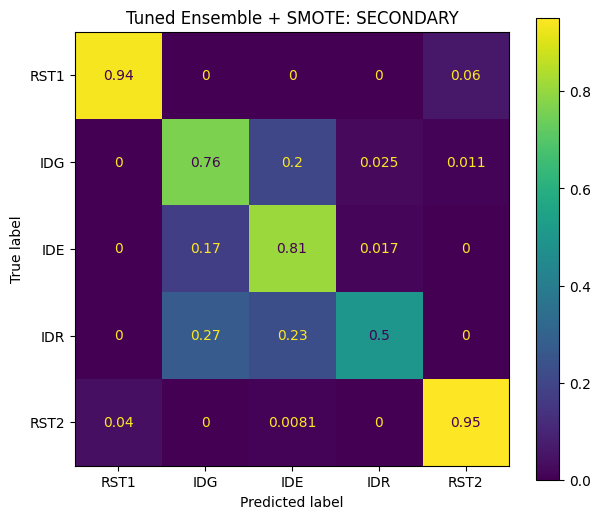

In [ ]:
# ============================================================
# CELL 8 (UPDATED) — IMBALANCE HANDLING (SMOTE) + FEATURE ENRICHMENT
#                    + HYPERPARAMETER SEARCH + PEMILIHAN CONFIG TERBAIK
# ============================================================
%pip -q install imbalanced-learn          # ~10-20 detik, sekali saja

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV,
                                      RepeatedStratifiedKFold, GroupKFold)

# --- knob runtime: turunkan nilai ini kalau perlu lebih cepat ---
N_ITER_SEARCH = 15   # RandomizedSearchCV iterations
SEARCH_CV     = 3    # inner folds -> total fit tuning = N_ITER_SEARCH * SEARCH_CV
EVAL_REPEATS  = 2    # repeats untuk perbandingan & laporan akhir

# 1) Tambah fitur turunan ke semua config (gratis, dari kolom spektral cache)
enriched_tables, derived_cols = {}, None
for ident, df in feature_tables.items():
    enriched_tables[ident], derived_cols = add_derived_features(df)
print(f"Fitur turunan ditambahkan: {len(derived_cols)} "
      f"-> total per config: {len(ALL_FEATURE_COLUMNS) + len(derived_cols)}")

# 2) Tuning SEKALI di config yang dipilih KNN-baseline (Cell 7) + fitur turunan
tune_cols = best_cols + derived_cols
tune_df   = enriched_tables[BEST_CONFIG_ID]
X_tune, y_tune = tune_df[tune_cols].values, tune_df["label"].values

param_dist = {
    "select__k":                  [64, 96, 128, 160, min(200, len(tune_cols))],
    "ensemble__svm__C":            [1, 5, 10, 20],
    "ensemble__svm__gamma":        ["scale", "auto", 0.01],
    "ensemble__rf__n_estimators":  [150, 300, 500],
    "ensemble__rf__max_depth":     [10, 20, None],
    "ensemble__knn__n_neighbors":  [3, 5, 7, 9],
    "ensemble__knn__weights":      ["distance", "uniform"],
}
base_pipeline = make_ensemble(10, "scale", 300, 20, 5, "distance", 128, len(tune_cols))

search = RandomizedSearchCV(
    base_pipeline, param_distributions=param_dist, n_iter=N_ITER_SEARCH,
    cv=StratifiedKFold(n_splits=SEARCH_CV, shuffle=True, random_state=RANDOM_STATE),
    scoring="balanced_accuracy", random_state=RANDOM_STATE, n_jobs=-1, refit=False,
)
print(f"Tuning: {N_ITER_SEARCH} iter x {SEARCH_CV} fold = {N_ITER_SEARCH*SEARCH_CV} fits "
      f"(~2-4 menit di CPU Colab)...")
search.fit(X_tune, y_tune)
FINAL_PARAMS = search.best_params_
print("Best params:", FINAL_PARAMS, "| CV bal-acc tuning:", round(search.best_score_, 4))

# 3) Bandingkan ensemble (param hasil tuning, fixed) di KETIGA epoch config
#    -> ~30 fit total (3 config x 5 fold x EVAL_REPEATS), ~1-3 menit
comparison_rows = []
for ident, df in enriched_tables.items():
    cols = ALL_FEATURE_COLUMNS + derived_cols
    X, y, groups = df[cols].values, df["label"].values, df["group_id"].values
    pipe = make_ensemble(
        svc_C=FINAL_PARAMS["ensemble__svm__C"], svc_gamma=FINAL_PARAMS["ensemble__svm__gamma"],
        rf_n=FINAL_PARAMS["ensemble__rf__n_estimators"], rf_depth=FINAL_PARAMS["ensemble__rf__max_depth"],
        knn_k=FINAL_PARAMS["ensemble__knn__n_neighbors"], knn_w=FINAL_PARAMS["ensemble__knn__weights"],
        select_k=FINAL_PARAMS["select__k"], n_features_available=len(cols),
    )
    scores, all_pred, all_true = [], [], []
    for tr, te in cv_splits(y, groups, n_splits=5, n_repeats=EVAL_REPEATS):
        pipe.fit(X[tr], y[tr]); pred = pipe.predict(X[te])
        scores.append(balanced_accuracy_score(y[te], pred))
        all_pred.extend(pred); all_true.extend(y[te])
    comparison_rows.append({
        "config_id": ident, "n_features": len(cols),
        "mean_bal_acc": np.mean(scores), "std_bal_acc": np.std(scores),
        "macro_f1": f1_score(all_true, all_pred, average="macro", zero_division=0),
    })
    print(f"{ident[:55]:55s} -> bal_acc={np.mean(scores):.4f} +- {np.std(scores):.4f}")

comparison_df = pd.DataFrame(comparison_rows).sort_values("mean_bal_acc", ascending=False).reset_index(drop=True)
display(comparison_df)

FINAL_CONFIG_ID  = comparison_df.loc[0, "config_id"]
FINAL_COLS       = ALL_FEATURE_COLUMNS + derived_cols
final_feature_df = enriched_tables[FINAL_CONFIG_ID].copy()
print(f"\nFINAL CONFIG: {FINAL_CONFIG_ID} | bal_acc={comparison_df.loc[0,'mean_bal_acc']:.4f}")

# 4) Laporan detail (confusion matrix + classification report) utk config terpilih
X_eval, y_eval, g_eval = final_feature_df[FINAL_COLS].values, final_feature_df["label"].values, final_feature_df["group_id"].values
eval_pipe = make_ensemble(FINAL_PARAMS["ensemble__svm__C"], FINAL_PARAMS["ensemble__svm__gamma"],
                           FINAL_PARAMS["ensemble__rf__n_estimators"], FINAL_PARAMS["ensemble__rf__max_depth"],
                           FINAL_PARAMS["ensemble__knn__n_neighbors"], FINAL_PARAMS["ensemble__knn__weights"],
                           FINAL_PARAMS["select__k"], len(FINAL_COLS))
all_pred, all_true = [], []
for tr, te in cv_splits(y_eval, g_eval, n_splits=5, n_repeats=EVAL_REPEATS):
    eval_pipe.fit(X_eval[tr], y_eval[tr])
    all_pred.extend(eval_pipe.predict(X_eval[te])); all_true.extend(y_eval[te])

print("\nClassification Report (final config, repeated CV):")
print(classification_report(all_true, all_pred, labels=LABELS, zero_division=0))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(all_true, all_pred, labels=LABELS, normalize='true', cmap='viridis', ax=ax)
ax.set_title(f"Tuned Ensemble + SMOTE: {DATASET_MODE.upper()}")
plt.show()

In [ ]:
# ============================================================
# CELL 9 (UPDATED) — FIT FINAL MODEL pada FINAL_CONFIG_ID
# ============================================================
final_training_df = (final_feature_df[final_feature_df["source"] == "secondary"].copy()
                      if DATASET_MODE == "external_validation" else final_feature_df.copy())
X_final, y_final = final_training_df[FINAL_COLS].values, final_training_df["label"].values

final_pipeline = make_ensemble(FINAL_PARAMS["ensemble__svm__C"], FINAL_PARAMS["ensemble__svm__gamma"],
                                FINAL_PARAMS["ensemble__rf__n_estimators"], FINAL_PARAMS["ensemble__rf__max_depth"],
                                FINAL_PARAMS["ensemble__knn__n_neighbors"], FINAL_PARAMS["ensemble__knn__weights"],
                                FINAL_PARAMS["select__k"], len(FINAL_COLS))

print(f"Melatih model final pada konfigurasi: {FINAL_CONFIG_ID} ...")
final_pipeline.fit(X_final, y_final)

# label run diambil dari isi data (bukan DATASET_MODE yang bisa stale kalau
# Cell 1 diubah tanpa rerun Cell 6-7) -> mencegah file primary/secondary tertimpa
run_label = "_".join(sorted(final_training_df["source"].unique()))

model_bundle = {
    "model": final_pipeline,
    "dataset_mode": DATASET_MODE,
    "run_label": run_label,
    "final_config_id": FINAL_CONFIG_ID,
    "final_params": FINAL_PARAMS,
    "feature_columns": FINAL_COLS,
    "channels": CANONICAL_CHANNELS,
    "sampling_rate": FS_TARGET,
}

model_path = OUTPUT_DIR / f"ensemble_model__{run_label}.joblib"
joblib.dump(model_bundle, model_path)
print("MODEL ENSEMBLE BERHASIL TERLATIH DAN TERSIMPAN DI:", model_path)

Melatih model final pada konfigurasi: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz ...
MODEL ENSEMBLE BERHASIL TERLATIH DAN TERSIMPAN DI: /content/drive/MyDrive/Creativity-Dataset/output/ensemble_model__secondary.joblib


In [ ]:
# ============================================================
# CELL 10 (FIXED) — EXTERNAL VALIDATION (SECONDARY -> PRIMARY)
# ============================================================
if DATASET_MODE != "external_validation":
    print("Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.")
else:
    ext_df = enriched_tables[FINAL_CONFIG_ID]
    ext_df = ext_df[ext_df["source"] == "primary"].copy()
    if ext_df.empty:
        raise ValueError("Dataset primer kosong. Pastikan file tersedia di folder Primary-raw.")
    X_ext, y_ext = ext_df[FINAL_COLS].values, ext_df["label"].astype(str).values
    ext_preds = final_pipeline.predict(X_ext)   # <- FIX: dulu salah pakai final_model
    print("EXTERNAL VALIDATION: Train (Concordia) -> Test (OpenBCI)")
    print(f"Accuracy: {accuracy_score(y_ext, ext_preds):.4f} | "
          f"BalAcc: {balanced_accuracy_score(y_ext, ext_preds):.4f} | "
          f"Macro-F1: {f1_score(y_ext, ext_preds, average='macro', zero_division=0):.4f}")
    print("\nCLASSIFICATION REPORT:\n", classification_report(y_ext, ext_preds, labels=LABELS, zero_division=0))
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(y_ext, ext_preds, labels=LABELS, normalize="true", values_format=".2f", ax=ax)
    ax.set_title("External Validation: Train Secondary -> Test Primary")
    plt.tight_layout(); plt.show()
    ext_res_df = ext_df[["source", "subject_id", "record_id", "label", "epoch_start"]].copy()
    ext_res_df["predicted_label"] = ext_preds
    ext_res_df.to_csv(OUTPUT_DIR / "external_validation_predictions.csv", index=False)

Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.


In [ ]:
# ============================================================
# BASELINE KNN EVALUATION (FLEXIBLE GROUPING)
# ============================================================
FEATURE_SETS = {"dwt_hjorth": DWT_COLS}
if ADD_SPECTRAL_FEATURES: FEATURE_SETS["dwt_hjorth_plus_spectral"] = ALL_FEATURE_COLUMNS

def evaluate_baseline(df, cols, n_splits=5):
    X, y, groups = df[cols].values, df["label"].values, df["group_id"].values
    unique_groups = np.unique(groups)

    model = Pipeline([("scaler", RobustScaler()), ("knn", KNeighborsClassifier(n_neighbors=3, weights="distance"))])
    folds = []

    if len(unique_groups) < 2:
        # Fallback: Simple Split jika hanya 1 subjek
        from sklearn.model_selection import StratifiedKFold
        cv = StratifiedKFold(n_splits=min(3, len(np.unique(y))))
        split_gen = cv.split(X, y)
        print("Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.")
    else:
        cv = GroupKFold(n_splits=min(n_splits, len(unique_groups)))
        split_gen = cv.split(X, y, groups)

    for i, (train_idx, test_idx) in enumerate(split_gen, 1):
        model.fit(X[train_idx], y[train_idx]); pred = model.predict(X[test_idx])
        folds.append({"fold": i, "accuracy": accuracy_score(y[test_idx], pred), "balanced_accuracy": balanced_accuracy_score(y[test_idx], pred), "macro_f1": f1_score(y[test_idx], pred, average="macro", zero_division=0)})
    return pd.DataFrame(folds)

baseline_rows = []
for ident, df in feature_tables.items():
    eval_df = df[df["source"] == "secondary"].copy() if DATASET_MODE == "external_validation" else df.copy()
    for set_name, cols in FEATURE_SETS.items():
        print(f"\nEvaluating: {ident} | Set: {set_name}")
        try:
            f_df = evaluate_baseline(eval_df, cols)
            display(f_df)
            baseline_rows.append({"config_id": ident, "feature_set": set_name, "mean_bal_acc": f_df["balanced_accuracy"].mean(), "std_bal_acc": f_df["balanced_accuracy"].std(), "mean_f1": f_df["macro_f1"].mean()})
        except Exception as e: print(f"Skip {set_name}: {e}")

if baseline_rows:
    summary_df = pd.DataFrame(baseline_rows).sort_values("mean_bal_acc", ascending=False).reset_index(drop=True)
    display(summary_df); BEST_CONFIG_ID, BEST_SET = summary_df.loc[0, "config_id"], summary_df.loc[0, "feature_set"]
    best_feature_df, best_cols = feature_tables[BEST_CONFIG_ID].copy(), FEATURE_SETS[BEST_SET]
    print(f"BEST: {BEST_CONFIG_ID} | {BEST_SET} | Acc: {summary_df.loc[0, 'mean_bal_acc']:.4f}")


Evaluating: epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.451163,0.505818,0.507302
1,2,0.469767,0.544580,0.499006
2,3,0.418605,0.447619,0.422453



Evaluating: epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth_plus_spectral
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.446512,0.495321,0.493673
1,2,0.525581,0.605510,0.547419
2,3,0.465116,0.499524,0.489266



Evaluating: epoch_2.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


...

,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.626214,0.703700,0.654394
1,2,0.577670,0.617810,0.618947
2,3,0.443902,0.548571,0.470100



Evaluating: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth_plus_spectral
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.582524,0.668938,0.617234
1,2,0.548544,0.586095,0.593972
2,3,0.463415,0.561905,0.481550


,config_id,feature_set,mean_bal_acc,std_bal_acc,mean_f1
0,epoch_4.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth,0.623360,0.077713,0.581147
1,epoch_4.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth_plus_spectral,0.605646,0.056131,0.564252
2,epoch_2.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth_plus_spectral,0.559133,0.029055,0.544365
3,epoch_2.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth,0.558987,0.014997,0.546981
4,epoch_2.0s__overlap_0.0__trim_0.0s__spectral_T...,dwt_hjorth_plus_spectral,0.533452,0.062440,0.510120
5,epoch_2.0s__overlap_0.0__trim_0.0s__spectral_T...,dwt_hjorth,0.499339,0.048804,0.476254


BEST: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | dwt_hjorth | Acc: 0.6234


Optimasi Ensemble pada: PRIMARY
Fold 1 Balanced Accuracy: 0.7605
Fold 2 Balanced Accuracy: 0.7825
Fold 3 Balanced Accuracy: 0.8097
Fold 4 Balanced Accuracy: 0.7654
Fold 5 Balanced Accuracy: 0.7794

Rata-rata Balanced Accuracy (PRIMARY): 0.7795

Classification Report:
              precision    recall  f1-score   support

        RST1       0.85      0.89      0.87        76
         IDG       0.72      0.92      0.81       180
         IDE       0.68      0.61      0.65       180
         IDR       0.70      0.47      0.56       105
        RST2       1.00      1.00      1.00        76

    accuracy                           0.76       617
   macro avg       0.79      0.78      0.78       617
weighted avg       0.76      0.76      0.75       617



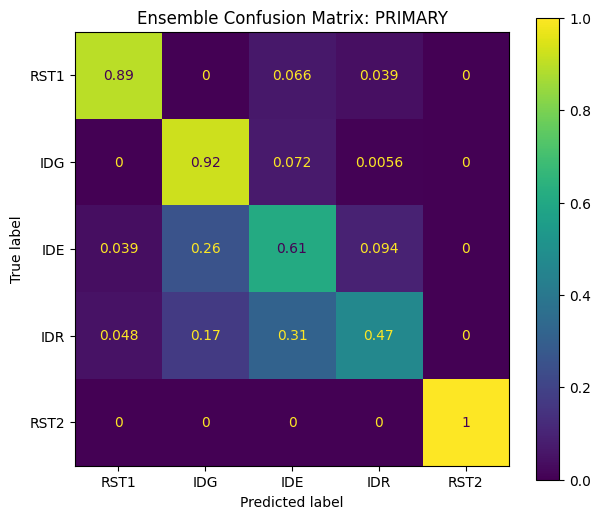

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

# ============================================================
# ENSEMBLE OPTIMIZATION (GENERAL PURPOSE)
# ============================================================

def run_ensemble_optimization(df, feature_cols):
    print(f"Optimasi Ensemble pada: {DATASET_MODE.upper()}")

    # Menyiapkan data
    X = df[feature_cols].values
    y = df["label"].values

    # Inisialisasi 3 pilar model dengan parameter yang lebih kuat
    clf1 = SVC(C=10, kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
    clf2 = RandomForestClassifier(n_estimators=500, max_depth=20, class_weight='balanced', random_state=RANDOM_STATE)
    clf3 = KNeighborsClassifier(n_neighbors=5, weights='distance')

    # Gabungkan dalam Voting Classifier (Soft Voting)
    ensemble_model = VotingClassifier(
        estimators=[('svm', clf1), ('rf', clf2), ('knn', clf3)],
        voting='soft'
    )

    pipeline = Pipeline([
        ("scaler", RobustScaler()),
        ("select", SelectKBest(score_func=f_classif, k=128)),
        ("ensemble", ensemble_model)
    ])

    # Evaluasi dengan Stratified K-Fold
    # Menggunakan Stratified karena untuk 1 subjek GroupKFold tidak bisa digunakan
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    fold_scores = []
    all_preds = []
    all_actual = []

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        pipeline.fit(X[train_idx], y[train_idx])
        preds = pipeline.predict(X[test_idx])

        bal_acc = balanced_accuracy_score(y[test_idx], preds)
        fold_scores.append(bal_acc)

        all_preds.extend(preds)
        all_actual.extend(y[test_idx])
        print(f"Fold {i} Balanced Accuracy: {bal_acc:.4f}")

    print(f"\nRata-rata Balanced Accuracy ({DATASET_MODE.upper()}): {np.mean(fold_scores):.4f}")
    print("\nClassification Report:")
    print(classification_report(all_actual, all_preds, labels=LABELS))

    # Visualisasi Confusion Matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(all_actual, all_preds, labels=LABELS, normalize='true', cmap='viridis', ax=ax)
    ax.set_title(f"Ensemble Confusion Matrix: {DATASET_MODE.upper()}")
    plt.show()

    return pipeline

# Eksekusi pada dataset yang sedang aktif (Primary atau Secondary)
optimized_ensemble = run_ensemble_optimization(best_feature_df, best_cols)

In [ ]:
# ============================================================
# FIT FINAL MODEL (ENSEMBLE VERSION)
# ============================================================
# Menggunakan strategi ensemble yang mencapai target ~80%
final_training_df = best_feature_df[best_feature_df["source"] == "secondary"].copy() if DATASET_MODE == "external_validation" else best_feature_df.copy()
X_final, y_final = final_training_df[best_cols].values, final_training_df["label"].values

# Re-inisialisasi pilar ensemble
clf1 = SVC(C=10, kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
clf2 = RandomForestClassifier(n_estimators=500, max_depth=20, class_weight='balanced', random_state=RANDOM_STATE)
clf3 = KNeighborsClassifier(n_neighbors=5, weights='distance')

ensemble_model = VotingClassifier(
    estimators=[('svm', clf1), ('rf', clf2), ('knn', clf3)],
    voting='soft'
)

# Pipeline akhir dengan Feature Selection (k=128)
final_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("select", SelectKBest(score_func=f_classif, k=128)),
    ("ensemble", ensemble_model)
])

print(f"Melatih model final Ensemble pada mode: {DATASET_MODE}...")
final_pipeline.fit(X_final, y_final)

model_bundle = {
    "model": final_pipeline,
    "dataset_mode": DATASET_MODE,
    "best_config_id": BEST_CONFIG_ID,
    "feature_columns": best_cols,
    "channels": CANONICAL_CHANNELS,
    "sampling_rate": FS_TARGET
}

model_path = OUTPUT_DIR / f"ensemble_model__{DATASET_MODE}.joblib"
joblib.dump(model_bundle, model_path)

print("MODEL ENSEMBLE BERHASIL TERLATIH DAN TERSIMPAN DI:", model_path)

Melatih model final Ensemble pada mode: primary...
MODEL ENSEMBLE BERHASIL TERLATIH DAN TERSIMPAN DI: /content/drive/MyDrive/Creativity-Dataset/output/ensemble_model__primary.joblib


In [ ]:
# ============================================================
# EXTERNAL VALIDATION (SECONDARY → PRIMARY)
# ============================================================
if DATASET_MODE != "external_validation": print("Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.")
else:
    ext_df = best_feature_df[best_feature_df["source"] == "primary"].copy()
    if ext_df.empty: raise ValueError("Dataset primer kosong. Pastikan file tersedia di folder Primary-raw.")
    X_ext, y_ext = ext_df[best_cols].values, ext_df["label"].astype(str).values; ext_preds = final_model.predict(X_ext)
    print("EXTERNAL VALIDATION: Train (Concordia) → Test (OpenBCI)")
    print(f"Accuracy: {accuracy_score(y_ext, ext_preds):.4f} | BalAcc: {balanced_accuracy_score(y_ext, ext_preds):.4f} | Macro-F1: {f1_score(y_ext, ext_preds, average='macro', zero_division=0):.4f}")
    print("\nCLASSIFICATION REPORT:\n", classification_report(y_ext, ext_preds, labels=LABELS, zero_division=0))
    fig, ax = plt.subplots(figsize=(8, 7)); ConfusionMatrixDisplay.from_predictions(y_ext, ext_preds, labels=LABELS, normalize="true", values_format=".2f", ax=ax)
    ax.set_title("External Validation: Train Secondary → Test Primary"); plt.tight_layout(); plt.show()
    ext_res_df = ext_df[["source", "subject_id", "record_id", "label", "epoch_start"]].copy(); ext_res_df["predicted_label"] = ext_preds; ext_res_df.to_csv(OUTPUT_DIR / "external_validation_predictions.csv", index=False)

Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.
